# Metodología Box Jenkins

In [1]:
#%pip install arch

In [2]:
#Importar las librerias

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from statsmodels.tsa.arima.model import ARIMA # Modelo ARIMA
from statsmodels.tsa.stattools import adfuller # Test de Dickey-Fuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf # Funciones para graficar ACF y PACF
from statsmodels.stats.diagnostic import acorr_ljungbox # Test de Ljung-Box
from statsmodels.sandbox.stats.runs import runstest_1samp # Test de rachas
from arch.unitroot import PhillipsPerron # Test de raíz unitaria
from statsmodels.tsa.seasonal import seasonal_decompose # Descomposición estacional
from statsmodels.graphics.gofplots import qqplot # Gráfico Q-Q
from statsmodels.stats.stattools import jarque_bera # Test de normalidad



- **cargar la data**

In [3]:
df=pd.read_csv('https://github.com/Wilsonsr/Series-de-Tiempo/raw/main/03_datos/06_estacionariedad/caffeine.csv')
df

,Unnamed: 0,x
0,1,0.429
1,2,0.443
2,3,0.451
3,4,0.455
4,5,0.440
...,...,...
173,174,0.393
174,175,0.394
175,176,0.389
176,177,0.391


In [4]:
df.drop(columns=['Unnamed: 0'], inplace=True)
df

,x
0,0.429
1,0.443
2,0.451
3,0.455
4,0.440
...,...
173,0.393
174,0.394
175,0.389
176,0.391


In [5]:
Fecha=pd.date_range(start='1/1/2025', periods=len(df), freq='D')
Fecha

DatetimeIndex(['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04',
               '2025-01-05', '2025-01-06', '2025-01-07', '2025-01-08',
               '2025-01-09', '2025-01-10',
               ...
               '2025-06-18', '2025-06-19', '2025-06-20', '2025-06-21',
               '2025-06-22', '2025-06-23', '2025-06-24', '2025-06-25',
               '2025-06-26', '2025-06-27'],
              dtype='datetime64[ns]', length=178, freq='D')

In [6]:
df["Fecha"]=Fecha # Agregar la columna de fecha
df

,x,Fecha
0,0.429,2025-01-01
1,0.443,2025-01-02
2,0.451,2025-01-03
3,0.455,2025-01-04
4,0.440,2025-01-05
...,...,...
173,0.393,2025-06-23
174,0.394,2025-06-24
175,0.389,2025-06-25
176,0.391,2025-06-26


In [7]:
df.set_index('Fecha', inplace=True)
df.head(3)

,x
Fecha,
2025-01-01,0.429
2025-01-02,0.443
2025-01-03,0.451


In [8]:
df.rename(columns={'x':'Concentracion'}, inplace=True)
df

,Concentracion
Fecha,
2025-01-01,0.429
2025-01-02,0.443
2025-01-03,0.451
2025-01-04,0.455
2025-01-05,0.440
...,...
2025-06-23,0.393
2025-06-24,0.394
2025-06-25,0.389


- gráfico de la serie

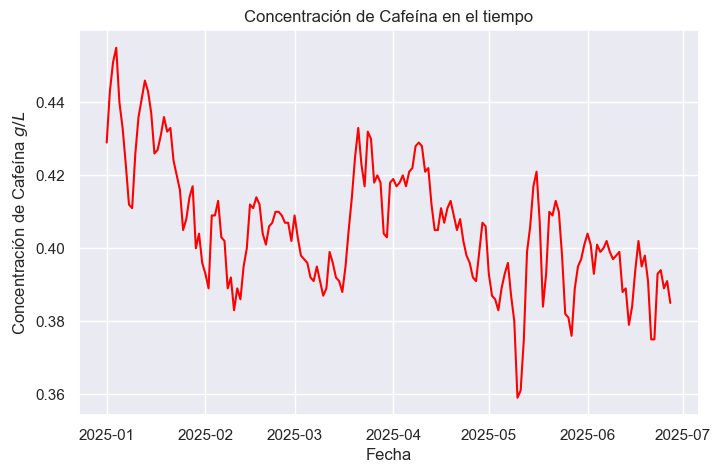

In [9]:
sns.set_theme()

plt.figure(figsize=(8,5)) # Tamaño de la figura
plt.plot(df.index, df['Concentracion'], color='red') # Gráfico de la serie de tiempo
plt.xlabel('Fecha')    # Etiqueta del eje x
plt.ylabel('Concentración de Cafeína $g/L$') # Etiqueta del eje y
plt.title('Concentración de Cafeína en el tiempo') # Título del gráfico
plt.show() # Mostrar el gráfico


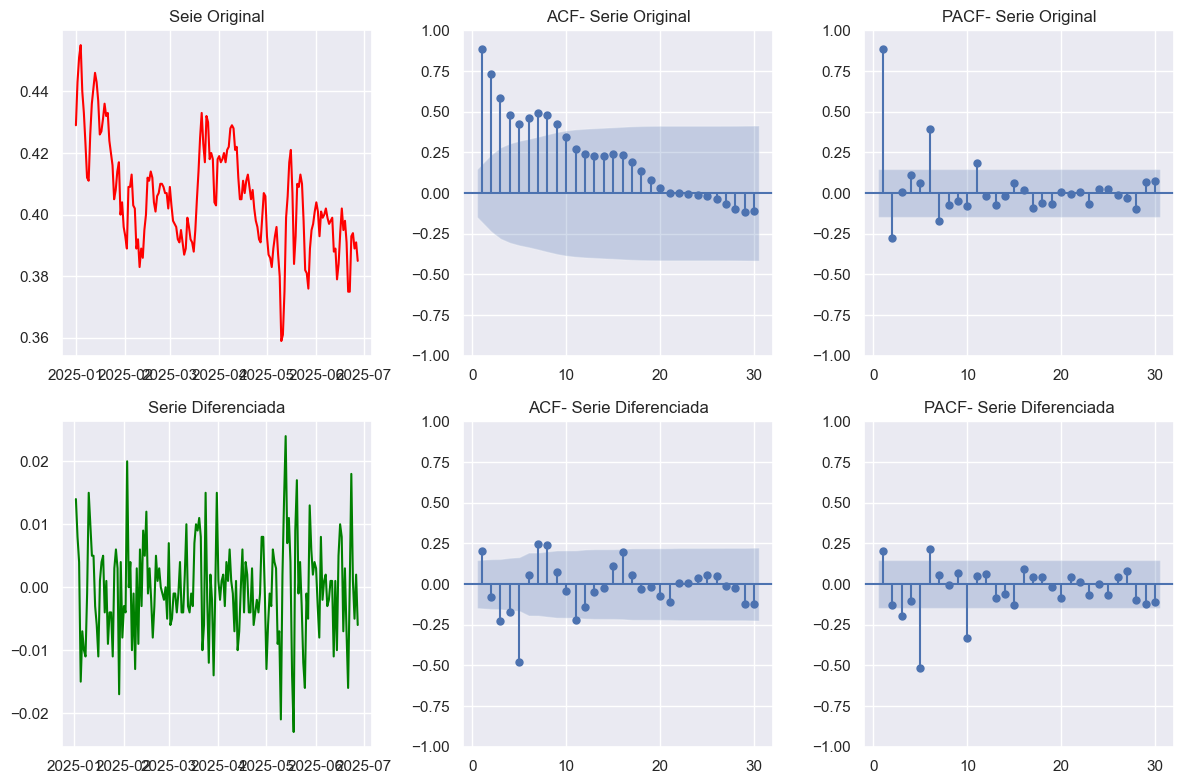

In [10]:
fig,  ax= plt.subplots(2,3, figsize=(12,8)) # Crear la figura y los ejes

ax[0,0].plot(df.index, df['Concentracion'], color='red') # Gráfico de la serie de tiempo
ax[0,0].set_title("Seie Original")

plot_acf(df['Concentracion'], ax=ax[0,1], lags=30, zero=False) # Gráfico de la función de autocorrelación
ax[0,1].set_title("ACF- Serie Original")

plot_pacf(df['Concentracion'], ax=ax[0,2], lags=30, zero=False) # Gráfico de la función de autocorrelación parcial
ax[0,2].set_title("PACF- Serie Original")

ax[1,0].plot(df.index, df['Concentracion'].diff(), color='green') # Gráfico de la serie de tiempo diferenciada
ax[1,0].set_title("Serie Diferenciada")

plot_acf(df['Concentracion'].diff().dropna(), ax=ax[1,1], lags=30, zero=False) # Gráfico de la función de autocorrelación
ax[1,1].set_title("ACF- Serie Diferenciada")

plot_pacf(df['Concentracion'].diff().dropna(), ax=ax[1,2], lags=30, zero=False) # Gráfico de la función de autocorrelación parcial
ax[1,2].set_title("PACF- Serie Diferenciada")

plt.tight_layout() # Ajustar el espacio entre los gráficos
plt.show() # Mostrar los gráficos

# Pruebas de Raiz unitaria -  Verficar estacionariedad

- Dickey Fuller
-  Phillips-Perron
  
$$
\begin{cases}
H_0: y_t \  \text{es no estacionaria}\\
H_1: y_t \  \text{es estacionaria}
\end{cases}
$$

Se rechaza $H_0$   si el valor p < 0.05

In [11]:
print("Dickey-Fuller Serie Original")
tes_dicke =adfuller(df['Concentracion'], autolag='AIC') # Test de Dickey-Fuller
print(f"Estadístico de prueba: {tes_dicke[0]}")
print(f"p-valor: {tes_dicke[1]}")

Dickey-Fuller Serie Original
Estadístico de prueba: -1.9913604296227123
p-valor: 0.2903740507254542


p-valor: 0.29037405072544553 > 0.05  la serie de tiempo del concentracion de cafeina es no estacionaria 

In [12]:
print("Phillips-Perron Serie Original")
tes_phillips = PhillipsPerron(df['Concentracion']) # Test de Phillips-Perron 
tes_phillips   

Phillips-Perron Serie Original


Test Statistic,-2.792
P-value,0.059
Lags,14


segun Phillips-Perron la serie de la concentracion  de cafeina es no estacionaria.

### Pruebas de raís unitaria con la serie diferenciada

In [13]:
print("Dickey-Fuller Serie diferenciada")
adf_dif= adfuller(df['Concentracion'].diff().dropna(), autolag='AIC') # Test de Dickey-Fuller
print(f"Estadístico de prueba: {adf_dif[0]}")
print(f"p-valor: {adf_dif[1]}") 

Dickey-Fuller Serie diferenciada
Estadístico de prueba: -5.941538569486249
p-valor: 2.2548601251494818e-07


In [14]:
PhillipsPerron(df['Concentracion'].diff().dropna()) # Test de Phillips-Perron

Test Statistic,-11.708
P-value,0.000
Lags,14


De acueroo a l test de Phillips Perron la serie diferenciada es estacionaria

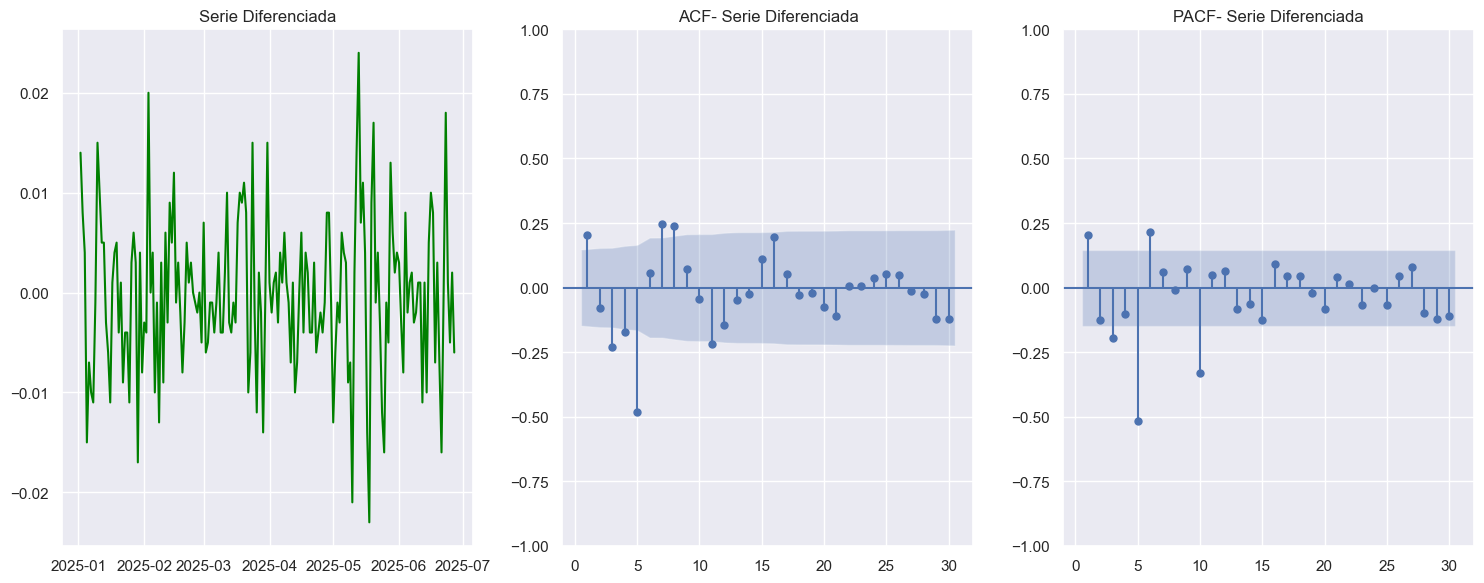

In [15]:
fig ,ax= plt.subplots(1,3, figsize=(15,6)) # Crear la figura y los ejes

ax[0].plot(df.index, df['Concentracion'].diff(), color='green') # Gráfico de la serie de tiempo diferenciada
ax[0].set_title("Serie Diferenciada")

plot_acf(df['Concentracion'].diff().dropna(), ax=ax[1], lags=30, zero=False) # Gráfico de la función de autocorrelación
ax[1].set_title("ACF- Serie Diferenciada")

plot_pacf(df['Concentracion'].diff().dropna(), ax=ax[2], lags=30, zero=False) # Gráfico de la función de autocorrelación parcial
ax[2].set_title("PACF- Serie Diferenciada")

plt.tight_layout() # Ajustar el espacio entre los gráficos
plt.show() # Mostrar los gráficos

Modelos

- ARIMA(5,1,0)
- ARIMA(6,1,0)
- ARIMA(10, 1, 0)
- ARIMA(0,1,8)
- ARIMA(0,1,5)
- ARIMA(5,1,5)

# Estimacion del modelo

### modelo 1  ARIMA (0,1,8)

In [16]:
modelo_1=ARIMA(df['Concentracion'], order=(0,1,8)).fit() # Modelo ARIMA(1,1,1)
print(modelo_1.summary()) # Resumen del modelo

c:\Users\wsand\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\wsand\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\wsand\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:          Concentracion   No. Observations:                  178
Model:                 ARIMA(0, 1, 8)   Log Likelihood                 674.865
Date:                Sat, 12 Sep 2026   AIC                          -1331.729
Time:                        09:18:50   BIC                          -1303.144
Sample:                    01-01-2025   HQIC                         -1320.136
                         - 06-27-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.3433      0.078      4.385      0.000       0.190       0.497
ma.L2         -0.0335      0.095     -0.353      0.724      -0.219       0.152
ma.L3         -0.2124      0.078     -2.731      0.0

## Diagnostico

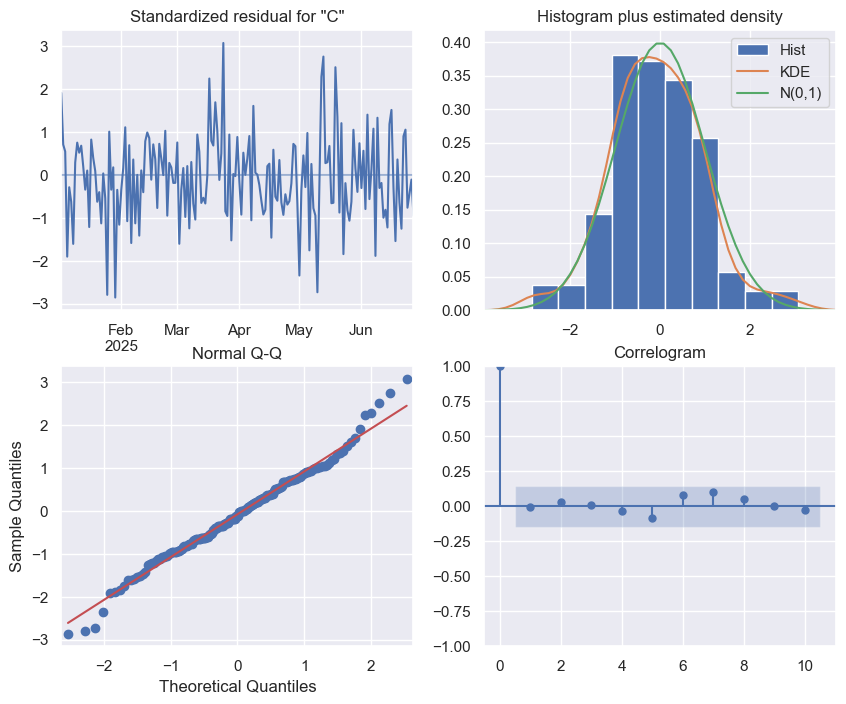

In [17]:
modelo_1.plot_diagnostics(figsize=(10,8)) # Diagnóstico del modelo
plt.show() # Mostrar los gráficos

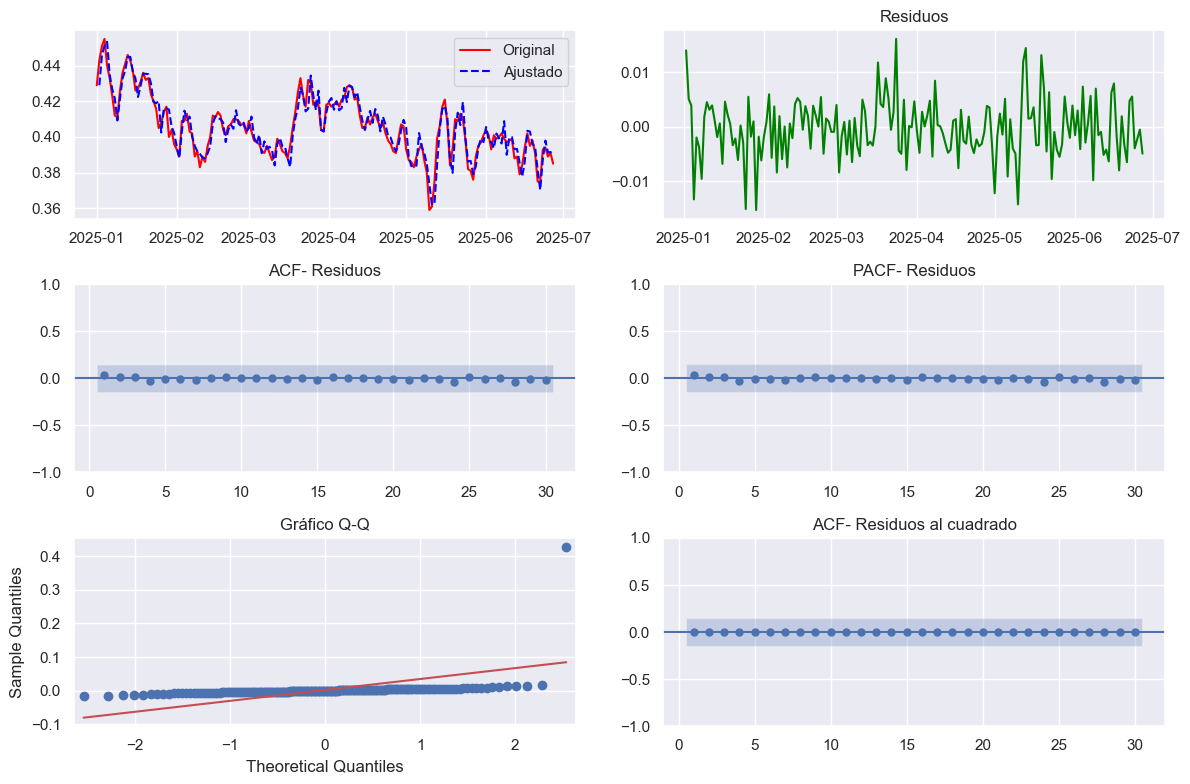

In [18]:
residuos=modelo_1.resid # Residuos del modelo


fig, ax= plt.subplots(3,2, figsize=(12,8)) # Crear la figura y los ejes

ax[0,0].plot(df.index, df['Concentracion'], color='red', label="Original") # Gráfico de la serie de tiempo
ax[0,0].plot(modelo_1.fittedvalues[1:], color='blue', linestyle="dashed", label="Ajustado")
ax[0,0].legend()

ax[0,1].plot(residuos[1:], color='green') # Gráfico de los residuos
ax[0,1].set_title("Residuos")

plot_acf(residuos, ax=ax[1,0], lags=30, zero=False) # Gráfico de la función de autocorrelación
ax[1,0].set_title("ACF- Residuos")  

plot_pacf(residuos, ax=ax[1,1], lags=30, zero=False) # Gráfico de la función de autocorrelación parcial
ax[1,1].set_title("PACF- Residuos")

qqplot(residuos, line='s', ax=ax[2,0]) # Gráfico Q-Q
ax[2,0].set_title("Gráfico Q-Q")

plot_acf(residuos**2, ax=ax[2,1], lags=30, zero=False) # Gráfico de la función de autocorrelación
ax[2,1].set_title("ACF- Residuos al cuadrado")

plt.tight_layout() # Ajustar el espacio entre los gráficos

### Prueba de Ljung-Box   correlacion serial en los residuales

$$
\begin{cases}
H_0: \text{Ausencia de correlacion serial en los residuales}\\
H_1: \text{Hay correlacion serial en los residuales}
\end{cases}
$$

objetivo.  **No rechazar**


$$
\begin{cases}
H_0: r_o=r_1=... r_k =0\\
H_1:  r_j \neq 0 \text{Para algun j}
\end{cases}
$$


In [19]:
Lj=modelo_1.test_serial_correlation(method='ljungbox') # Test de Ljung-Box
Lj


array([[[2.51540774e-03, 1.45895112e-01, 1.57755382e-01, 3.49940720e-01,
         1.74048353e+00, 2.91178374e+00, 4.85449358e+00, 5.42452189e+00,
         5.42499312e+00, 5.53706422e+00],
        [9.59999795e-01, 9.29649583e-01, 9.84102302e-01, 9.86366353e-01,
         8.83760568e-01, 8.19834716e-01, 6.77714698e-01, 7.11387219e-01,
         7.95799562e-01, 8.52543514e-01]]])

In [20]:
acorr_ljungbox(residuos, lags=15) # Test de Ljung-Box


,lb_stat,lb_pvalue
1,0.195011,0.658779
2,0.227596,0.892438
3,0.244711,0.970068
4,0.416572,0.981098
5,0.423904,0.994646
6,0.430387,0.998585
7,0.494530,0.999466
8,0.501769,0.999865
9,0.524530,0.999963
10,0.533885,0.999991


##  Normalidad 

$$
\begin{cases}
H_0: \text{Los redsiduales siguen una distribucion normal}\\
H_1: \text{Los residuales no siguen una distribucion normal}
\end{cases}
$$

In [21]:
modelo_1.test_normality(method='jarquebera')

array([[3.47306399, 0.17613016, 0.11374942, 3.64743201]])

In [22]:
modelo_1.test_normality(method='jarquebera')

array([[3.47306399, 0.17613016, 0.11374942, 3.64743201]])

In [23]:
help(jarque_bera)

Help on function jarque_bera in module statsmodels.stats.stattools:

jarque_bera(resids, axis=0)
    The Jarque-Bera test of normality.

    Parameters
    ----------
    resids : array_like
        Data to test for normality. Usually regression model residuals that
        are mean 0.
    axis : int, optional
        Axis to use if data has more than 1 dimension. Default is 0.

    Returns
    -------
    JB : {float, ndarray}
        The Jarque-Bera test statistic.
    JBpv : {float, ndarray}
        The pvalue of the test statistic.
    skew : {float, ndarray}
        Estimated skewness of the data.
    kurtosis : {float, ndarray}
        Estimated kurtosis of the data.

    Notes
    -----
    Each output returned has 1 dimension fewer than data

    The Jarque-Bera test statistic tests the null that the data is normally
    distributed against an alternative that the data follow some other
    distribution. The test statistic is based on two moments of the data,
    the skewness, 

In [24]:
jarque_bera(residuos) # Test de normalidad

(np.float64(203226.46944395415),
 np.float64(0.0),
 np.float64(12.687994885051882),
 np.float64(166.57683474736857))

In [25]:
# Test de normalidad

Aleatoriedad  tes de rachas

$$
\begin{cases}
H_0: \text{Los redsiduales son aleatorios}\\
H_1: \text{Los residuales no son aleatorios}
\end{cases}
$$

In [26]:
estadis, pvalor = runstest_1samp(residuos) # Test de rachas
print(f"Estadístico de prueba: {estadis}")
print(f"p-valor: {pvalor}")

Estadístico de prueba: -1.3544537248534405
p-valor: 0.17559166732821785


pronostico=modelo

Concl:  los Resdiduales siguen una distribucion normal

Pronostico

In [27]:
modelo_1.get_prediction(start='2025-06-28', end='2025-07-05').summary_frame(alpha=0.05) # Predicción

Concentracion,mean,mean_se,mean_ci_lower,mean_ci_upper
2025-06-28,0.376015,0.005228,0.365767,0.386262
2025-06-29,0.376932,0.008756,0.359771,0.394092
2025-06-30,0.382798,0.011115,0.361012,0.404584
2025-07-01,0.384126,0.012509,0.359610,0.408643
2025-07-02,0.386665,0.014006,0.359214,0.414116
2025-07-03,0.386955,0.014171,0.359179,0.414731
2025-07-04,0.386005,0.014212,0.358150,0.413860
2025-07-05,0.384585,0.014339,0.356481,0.412689


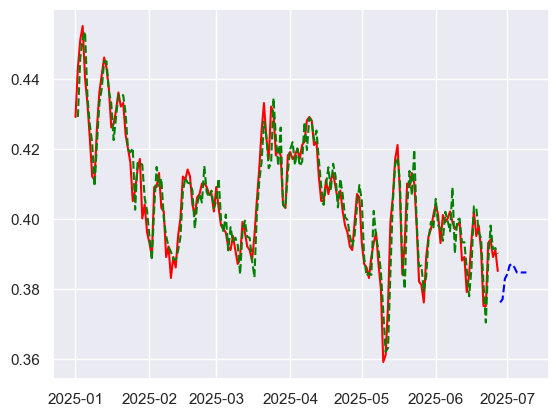

In [28]:
pronostico= modelo_1.forecast(steps=12) # Pronóstico de 12 pasos


plt.plot(df.index, df['Concentracion'], color='red', label="Original") # Gráfico de la serie de tiempo

plt.plot(pronostico, color='blue', linestyle="dashed", label="Pronóstico")
plt.plot(modelo_1.fittedvalues[1:], color='green', linestyle="dashed", label="Ajustado")


|modelo | BIC  |  Ljung-Box | Normalidad  |   Aleatoriedad|
|---|---|---|---|---|
|ARIMA(0,1,8) |-1303.138| ok|ok| ok |